# Homogenized Procedural Locomotion: Swim, Idle & Sprint

This notebook provides a unified, fully homogenized procedural animation generator for all aquatic organisms (fish, sharks, and cetaceans).

---

### Core Principles of Homogenization:
1. **Zero Per-Species Hardcoding**: All organisms (sharks, dolphins, tuna, whales, goldfish) share the exact same underlying kinematic laws and clip parameters.
2. **Automatic Organism Adaptation**: The pipeline automatically adapts the undulation plane from detected tail geometry (`vertical` -> lateral yaw; `horizontal` -> sagittal pitch).
3. **Standardized Locomotion Suite**:
   - **`Swim`**: Propulsive locomotion with anchored snout ($A_0 = 0.08 \cdot A_{\max}$) and synchronized fin stroke.
   - **`Idle`**: Baseline gentle water hovering ($A = 0.06, T = 3.5\text{s}$) from `fish.py` with calm fin hovering.
   - **`Sprint`**: High-speed sprint ($T = 0.85\text{s}, A = 0.30, A_0 = 0.14 \cdot A_{\max}$) with streamlined side fins folded flat against the body.

In [1]:
import sys
sys.path.insert(0, "..")

from pathlib import Path
import numpy as np
import trimesh
import pygltflib
import torch
import matplotlib.pyplot as plt

from animgen.core.models.model import BaseModelClass
from animgen.core.models.fish import FishModels, DEFAULT_FISH_PARAMS
from animgen.core.armature import Armature
from animgen.animation.animator import AnimationClip
from animgen.animation.kinematics import successive_rotations
from animgen.io.glb_output import export_glb

MODELS_DIR = Path("../generated_data/models")
TUNED_OUT_DIR = Path("../generated_data/test/animation_tuning")
TUNED_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Homogenized Clip Configurations across all aquatic species
LOCOMOTION_CONFIGS = {
    "swim": {
        "wave_amplitude": 0.22,
        "wave_duration": 1.4,
        "num_waves": 0.85,
        "head_amplitude_ratio": 0.08,
        "pectoral_mode": "active",
        "pectoral_flap_deg": 14.0,
        "pectoral_pitch_deg": 6.0,
        "dorsal_flex_deg": 4.0,
    },
    "idle": {
        "wave_amplitude": DEFAULT_FISH_PARAMS["animations"]["idle"]["wave_amplitude"],  # 0.06
        "wave_duration": DEFAULT_FISH_PARAMS["animations"]["idle"]["wave_duration"],    # 3.5s
        "num_waves": DEFAULT_FISH_PARAMS["animations"]["idle"]["num_waves"],            # 1.0
        "head_amplitude_ratio": 0.04,
        "pectoral_mode": "active",
        "pectoral_flap_deg": 4.0,
        "pectoral_pitch_deg": 2.0,
        "dorsal_flex_deg": 1.5,
    },
    "sprint": {
        "wave_amplitude": 0.30,
        "wave_duration": 0.85,
        "num_waves": 0.85,
        "head_amplitude_ratio": 0.14,
        "pectoral_mode": "closed",  # Standard streamlined body tuck
        "pectoral_close_deg": 35.0,
        "dorsal_flex_deg": 5.0,
    },
}

print("Homogenized Locomotion Suite Configurations:")
for name, cfg in LOCOMOTION_CONFIGS.items():
    print(f"  [{name.upper():6s}] amp={cfg['wave_amplitude']}, dur={cfg['wave_duration']}s, head_ratio={cfg['head_amplitude_ratio']}, fin_mode={cfg['pectoral_mode']}")
print(f"\nTarget output directory: {TUNED_OUT_DIR.resolve()}")

Homogenized Locomotion Suite Configurations:
  [SWIM  ] amp=0.22, dur=1.4s, head_ratio=0.08, fin_mode=active
  [IDLE  ] amp=0.06, dur=3.5s, head_ratio=0.04, fin_mode=active
  [SPRINT] amp=0.3, dur=0.85s, head_ratio=0.14, fin_mode=closed

Target output directory: /media/kahnsvaer/Datasets/PsnlProjects/AnimationGenerationGSoC/generated_data/test/animation_tuning


## 1. Unified Locomotion Wave Generator

Synthesizes full-body swimming deformations along the 12-bone longitudinal spine chain and coordinates secondary pectoral & dorsal appendages.

In [2]:
def _to_numpy(arr):
    if isinstance(arr, torch.Tensor):
        return arr.detach().cpu().numpy()
    return np.asarray(arr)


def generate_natural_swimming_animation(
    armature: Armature,
    wave_amplitude: float = 0.22,
    wave_duration: float = 1.4,
    frame_rate: float = 30.0,
    head_amplitude_ratio: float = 0.08,
    num_waves: float = 0.85,
    tail_orientation: str = "vertical",
    pectoral_mode: str = "active",  # 'active', 'closed'
    pectoral_flap_deg: float = 14.0,
    pectoral_pitch_deg: float = 6.0,
    pectoral_close_deg: float = 35.0,
    dorsal_flex_deg: float = 4.0,
) -> dict[float, list[np.ndarray]]:
    """
    Unified procedural animation generator for all aquatic organisms.
    """
    # 1. Identify all longitudinal spine & tail bones
    spine_indices = [
        i for i, b in enumerate(armature.bones_list)
        if "pectoral" not in b.id and "dorsal" not in b.id
    ]
    bones = [armature.bones_list[i] for i in spine_indices]
    
    # 2. Extract cumulative arc-length distances along the spine
    positions = [np.array(bones[0].head, dtype=np.float64)]
    for b in bones:
        positions.append(np.array(b.tail, dtype=np.float64))
    positions = np.array(positions)
    
    seg_vectors = np.diff(positions, axis=0)
    seg_lengths = np.linalg.norm(seg_vectors, axis=1)
    cum_dist = np.concatenate(([0.0], np.cumsum(seg_lengths)))
    total_len = cum_dist[-1]
    norm_s = cum_dist / max(total_len, 1e-6)
    
    # 3. Smooth Quadratic Envelope: Anchors snout and smoothly expands toward caudal fin
    envelope = head_amplitude_ratio + (1.0 - head_amplitude_ratio) * (norm_s ** 2)
    
    num_frames = int(round(wave_duration * frame_rate))
    times = np.linspace(0.0, wave_duration, num_frames, endpoint=False)
    omega = 2.0 * np.pi / wave_duration
    k = 2.0 * np.pi * num_waves / total_len
    
    bind_positions = np.stack([cum_dist, np.zeros_like(cum_dist), np.zeros_like(cum_dist)], axis=-1)
    
    # Steer rotation: Fish undulate across Z (transverse/yaw), Cetaceans across Y (sagittal/pitch)
    if tail_orientation == "vertical":
        steer_rot = trimesh.transformations.rotation_matrix(np.pi / 2, [1, 0, 0])[:3, :3]
    else:
        steer_rot = np.eye(3)
        
    l_pec_idx = next((i for i, b in enumerate(armature.bones_list) if "left_pectoral" in b.id), None)
    r_pec_idx = next((i for i, b in enumerate(armature.bones_list) if "right_pectoral" in b.id), None)
    dorsal_idx = next((i for i, b in enumerate(armature.bones_list) if "dorsal" in b.id), None)
    
    num_total_bones = len(armature.bones_list)
    animation: dict[float, list[np.ndarray]] = {}
    
    for t in times:
        phase = k * cum_dist - omega * t
        amp = wave_amplitude * envelope
        d_env_ds = np.gradient(amp, cum_dist)
        dy_dx = d_env_ds * np.sin(phase) + amp * k * np.cos(phase)
        
        tangents = np.stack([np.ones_like(dy_dx), dy_dx, np.zeros_like(dy_dx)], axis=-1)
        tangents /= np.linalg.norm(tangents, axis=-1, keepdims=True)
        
        frame_pts = [np.array([0.0, 0.0, 0.0])]
        for i in range(len(seg_lengths)):
            frame_pts.append(frame_pts[-1] + seg_lengths[i] * tangents[i])
        frame_pts = np.array(frame_pts)
        frame_pts[:, 1] -= np.mean(frame_pts[:, 1])
        
        raw_rots = successive_rotations(bind_positions, frame_pts, is_positions=True)
        rot_matrices = [_to_numpy(R) for R in raw_rots]
        if steer_rot is not None:
            rot_matrices = [steer_rot @ R @ steer_rot.T for R in rot_matrices]
            
        full_frame = [np.eye(3, dtype=np.float32) for _ in range(num_total_bones)]
        for idx_in_spine, bone_idx in enumerate(spine_indices):
            full_frame[bone_idx] = rot_matrices[idx_in_spine].astype(np.float32)
            
        # Pectoral Fin Kinematics
        if pectoral_mode == "closed":
            # Standard streamlined tuck against lateral body wall
            tuck_angle = np.radians(pectoral_close_deg)
            flutter = np.radians(2.0) * np.sin(omega * t)
            if l_pec_idx is not None:
                R_fold_l = trimesh.transformations.rotation_matrix(-tuck_angle, [0, 1, 0])[:3, :3]
                R_roll_l = trimesh.transformations.rotation_matrix(flutter, [1, 0, 0])[:3, :3]
                full_frame[l_pec_idx] = (R_fold_l @ R_roll_l).astype(np.float32)
            if r_pec_idx is not None:
                R_fold_r = trimesh.transformations.rotation_matrix(tuck_angle, [0, 1, 0])[:3, :3]
                R_roll_r = trimesh.transformations.rotation_matrix(-flutter, [1, 0, 0])[:3, :3]
                full_frame[r_pec_idx] = (R_fold_r @ R_roll_r).astype(np.float32)
        else:  # 'active'
            flap_angle = np.radians(pectoral_flap_deg) * np.sin(omega * t + np.pi / 4)
            pitch_angle = np.radians(pectoral_pitch_deg) * np.cos(omega * t + np.pi / 4)
            if l_pec_idx is not None:
                R_roll_l = trimesh.transformations.rotation_matrix(flap_angle, [1, 0, 0])[:3, :3]
                R_pitch_l = trimesh.transformations.rotation_matrix(pitch_angle, [0, 1, 0])[:3, :3]
                full_frame[l_pec_idx] = (R_roll_l @ R_pitch_l).astype(np.float32)
            if r_pec_idx is not None:
                R_roll_r = trimesh.transformations.rotation_matrix(-flap_angle, [1, 0, 0])[:3, :3]
                R_pitch_r = trimesh.transformations.rotation_matrix(pitch_angle, [0, 1, 0])[:3, :3]
                full_frame[r_pec_idx] = (R_roll_r @ R_pitch_r).astype(np.float32)
                
        # Dorsal Fin Stabilization Flexing
        if dorsal_idx is not None:
            d_angle = np.radians(dorsal_flex_deg) * np.sin(omega * t - np.pi / 3)
            R_dorsal = trimesh.transformations.rotation_matrix(d_angle, [0, 0, 1])[:3, :3]
            full_frame[dorsal_idx] = R_dorsal.astype(np.float32)
            
        animation[float(t)] = full_frame
        
    return animation

## 2. Visual Diagnostics: Standardized Wave Envelopes

Comparison of the amplitude envelopes and spine displacement curves across the standardized `Swim`, `Idle`, and `Sprint` locomotion modes.

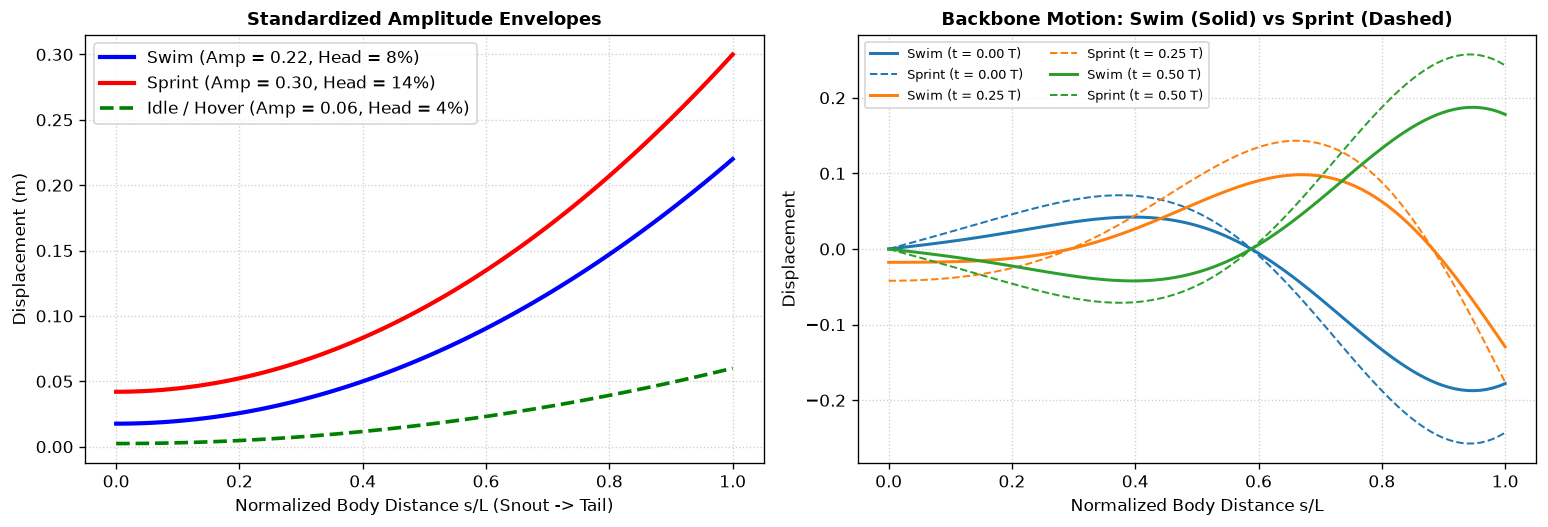

In [3]:
s = np.linspace(0.0, 1.0, 100)
env_swim = 0.08 + (1.0 - 0.08) * (s ** 2)
env_idle = 0.04 + (1.0 - 0.04) * (s ** 2)
env_sprint = 0.14 + (1.0 - 0.14) * (s ** 2)

plt.figure(figsize=(13, 4.5), dpi=120)

# Subplot 1: Amplitude Envelopes
plt.subplot(1, 2, 1)
plt.plot(s, 0.22 * env_swim, 'b-', lw=2.5, label="Swim (Amp = 0.22, Head = 8%)")
plt.plot(s, 0.30 * env_sprint, 'r-', lw=2.5, label="Sprint (Amp = 0.30, Head = 14%)")
plt.plot(s, 0.06 * env_idle, 'g--', lw=2.2, label="Idle / Hover (Amp = 0.06, Head = 4%)")
plt.title("Standardized Amplitude Envelopes", fontsize=11, fontweight='bold')
plt.xlabel("Normalized Body Distance s/L (Snout -> Tail)", fontsize=10)
plt.ylabel("Displacement (m)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True)

# Subplot 2: Backbone Undulation Comparison
plt.subplot(1, 2, 2)
for phase_frac, col in [(0.0, '#1f77b4'), (0.25, '#ff7f0e'), (0.50, '#2ca02c')]:
    y_swim = 0.22 * env_swim * np.sin(2.0 * np.pi * (0.85 * s - phase_frac))
    y_sprint = 0.30 * env_sprint * np.sin(2.0 * np.pi * (0.85 * s - phase_frac))
    plt.plot(s, y_swim, color=col, lw=1.8, label=f"Swim (t = {phase_frac:.2f} T)")
    plt.plot(s, y_sprint, color=col, lw=1.2, linestyle="--", label=f"Sprint (t = {phase_frac:.2f} T)")

plt.title("Backbone Motion: Swim (Solid) vs Sprint (Dashed)", fontsize=11, fontweight='bold')
plt.xlabel("Normalized Body Distance s/L", fontsize=10)
plt.ylabel("Displacement", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(frameon=True, loc="upper left", fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 3. Homogenized Multi-Clip Batch Pipeline (`Swim` + `Idle` + `Sprint`)

Iterates over any list of input GLB models, autorigs them, synthesizes the complete standardized animation suite, and exports all models with **full PBR textures and UV mapping** intact.

In [4]:
TARGET_MODELS = [
    ("shark", MODELS_DIR / "paint_mesh_Shark.glb"),
    ("dolphin", MODELS_DIR / "paint_mesh_Dolphin.glb"),
    ("tuna", MODELS_DIR / "paint_mesh_Tuna.glb"),
    ("killer_whale", MODELS_DIR / "paint_mesh_Killer_Whale.glb"),
    ("mackeral", MODELS_DIR / "paint_mesh_Mackeral.glb"),
    ("goldfish", MODELS_DIR / "paint_mesh_Goldfish.glb"),
]

for name, mesh_path in TARGET_MODELS:
    if not mesh_path.exists():
        print(f"Skipping {name}, path not found: {mesh_path}")
        continue
        
    print(f"\n{'='*60}\nProcessing {name.upper()} through Homogenized Pipeline...\n{'='*60}")
    
    # 1. Load mesh keeping original TextureVisuals & PBR material intact
    raw_mesh = trimesh.load(mesh_path, force="mesh")
    model = BaseModelClass(raw_mesh)
    
    # 2. Autorig
    fish = FishModels(model=model, use_sam=True, rig_dorsal_fin=True)
    fish.segment()
    fish.autorig()
    armature = fish.armature
    print(f"  -> Autorigged {len(armature.bones_list)} bones (Detected tail: {fish.tail_orientation})")
    
    # 3. Generate Homogenized Clip Suite (Swim, Idle, Sprint)
    all_clips = []
    for clip_key, cfg in LOCOMOTION_CONFIGS.items():
        anim_dict = generate_natural_swimming_animation(
            armature=armature,
            tail_orientation=fish.tail_orientation,
            **cfg,
        )
        clip = AnimationClip(name=clip_key.capitalize(), duration=cfg["wave_duration"], armature=armature)
        clip.positions = anim_dict
        all_clips.append(clip)
    
    # 4. Compute skin weights & Export multi-clip GLB
    model.armature = armature
    skin_weights = model.compute_skin_weights()
    
    out_glb = TUNED_OUT_DIR / f"{name}_natural_swim.glb"
    export_glb(
        mesh=model.mesh,
        output_path=out_glb,
        armature=armature,
        skin_weights=skin_weights,
        animation=all_clips,
    )
    
    # 5. Validate exported GLB
    g = pygltflib.GLTF2().load(str(out_glb))
    anim_names = [a.name for a in g.animations]
    print(f"  -> Exported: {out_glb}")
    print(f"  [VALIDATION] Materials: {len(g.materials)} | Textures: {len(g.textures)} | Skins: {len(g.skins)} | Tracks: {anim_names}")



Processing SHARK through Homogenized Pipeline...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:02<00:00,  8.37it/s]


  -> Autorigged 15 bones (Detected tail: vertical)
  -> Exported: ../generated_data/test/animation_tuning/shark_natural_swim.glb
  [VALIDATION] Materials: 1 | Textures: 1 | Skins: 1 | Tracks: ['Swim', 'Idle', 'Sprint']

Processing DOLPHIN through Homogenized Pipeline...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

...

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 10.71it/s]


  -> Autorigged 15 bones (Detected tail: vertical)
  -> Exported: ../generated_data/test/animation_tuning/mackeral_natural_swim.glb
  [VALIDATION] Materials: 1 | Textures: 1 | Skins: 1 | Tracks: ['Swim', 'Idle', 'Sprint']

Processing GOLDFISH through Homogenized Pipeline...


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Rendering Multiviews...: 100%|██████████| 20/20 [00:01<00:00, 10.35it/s]


  -> Autorigged 15 bones (Detected tail: vertical)
  -> Exported: ../generated_data/test/animation_tuning/goldfish_natural_swim.glb
  [VALIDATION] Materials: 1 | Textures: 1 | Skins: 1 | Tracks: ['Swim', 'Idle', 'Sprint']


## 4. Inspection & Viewing in Blender

1. **Import in Blender**: Go to **File -> Import -> glTF 2.0** and pick any file from `scratch/visual_exports/animation_tuning/`.
2. **Enable Textures**: Press <kbd>Z</kbd> and choose **Material Preview**.
3. **Switch Animation Clips**:
   - Open the **Dope Sheet** or **Action Editor** in Blender.
   - Toggle seamlessly between **`Swim`**, **`Idle`**, and **`Sprint`**.
   - Hit <kbd>Spacebar</kbd> to play and inspect!